<a href="https://colab.research.google.com/github/Viswas-Vinayakumar/Cloudnotes/blob/main/LCP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food parsing: error analysis

A structured extraction task. Input is free-text meal logs.
Output is JSON with item, quantity, unit.

This notebook measures how well the parser works and why it fails.
The parser itself is five lines. The measurement is the point.

Model: openai/gpt-oss-120b via Groq. temperature=0 for repeatable runs.

Three steps: prompt template -> model -> JSON parser.
Kept deliberately simple so failures come from the prompt

In [1]:
!pip install -qU langchain-groq

from google.colab import userdata
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

llm = ChatGroq(
    api_key=userdata.get('langchaingroqapi'),
    model="openai/gpt-oss-120b",
    temperature=0,
)

prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Extract foods from the text. Return JSON with a list called items. "
     "Each item has: item, quantity, unit. Use null if not stated. "
     "Return only JSON, no other text."),
    ("human", "{text}"),
])

chain = prompt | llm | JsonOutputParser()

tests = [
    "200g magerquark",
    "2 boiled eggs",
    "a handful of almonds",
    "2 Eier und 200g Magerquark",
    "skipped breakfast today",
]

for t in tests:
    print(t)
    print("   ->", chain.invoke({"text": t}))
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.5 MB/s eta 0:00:00
200g magerquark
   -> {'items': [{'item': 'magerquark', 'quantity': 200, 'unit': 'g'}]}

2 boiled eggs
   -> {'items': [{'item': 'boiled eggs', 'quantity': 2, 'unit': None}]}

a handful of almonds
   -> {'items': [{'item': 'almonds', 'quantity': 'handful', 'unit': None}]}

2 Eier und 200g Magerquark
   -> {'items': [{'item': 'Eier', 'quantity': 2, 'unit': None}, {'item': 'Magerquark', 'quantity': 200, 'unit': 'g'}]}

skipped breakfast today
   -> {'items': []}



## Test cases

Five inputs, chosen to cover different input shapes:
clean, countable, vague quantity, German, no food.
Four of the five are expected to expose a problem.

## Findings

| # | Input | Result | What went wrong |
|---|-------|--------|-----------------|
| 1 | 200g magerquark | pass | - |
| 2 | 2 boiled eggs | fail | plural name, includes cooking method |
| 3 | a handful of almonds | fail | quantity is text, not a number |
| 4 | 2 Eier und 200g Magerquark | fail | capitalised, German word kept |
| 5 | skipped breakfast today | pass | - |

All four failures trace back to rules missing from the prompt.
The prompt never asked for lowercase, singular names, English
translation, or numeric quantities.

Failure 3 is the most serious. A text quantity will crash any
code that does arithmetic on it. The others are cosmetic.

In [3]:
from typing import List, Optional
from pydantic import BaseModel, Field

class FoodItem(BaseModel):
    item: str = Field(
        description="food name, lowercase, singular, English"
    )
    quantity: Optional[float] = Field(
        default=None,
        description="a number only. null if no amount was stated"
    )
    unit: Optional[str] = Field(
        default=None,
        description="one of: g, ml, piece, scoop, tbsp. null if not stated"
    )

class ParsedEntry(BaseModel):
    items: List[FoodItem]


structured_llm = llm.with_structured_output(ParsedEntry)
chain2 = prompt | structured_llm

for t in tests:
    print(t)
    print("   ->", chain2.invoke({"text": t}))
    print()

200g magerquark
   -> items=[FoodItem(item='quark', quantity=200.0, unit='g')]

2 boiled eggs
   -> items=[FoodItem(item='egg', quantity=2.0, unit=None)]

a handful of almonds
   -> items=[FoodItem(item='almond', quantity=1.0, unit='handful')]

2 Eier und 200g Magerquark
   -> items=[FoodItem(item='egg', quantity=2.0, unit=None), FoodItem(item='quark', quantity=200.0, unit='g')]

skipped breakfast today
   -> items=[]



## Scoreboard: prompt-only vs Pydantic schema

| # | Input | Before | After |
|---|-------|--------|-------|
| 1 | 200g magerquark | pass | **fail** — became `quark`, fat level lost |
| 2 | 2 boiled eggs | fail — plural name, cooking method kept | fail — unit missing, should be `piece` |
| 3 | a handful of almonds | fail — `quantity='handful'` (text) | fail — text moved to `unit='handful'` |
| 4 | 2 Eier und 200g Magerquark | fail — German kept, capitalised | **pass** |
| 5 | skipped breakfast today | pass | pass |

**2/5 before, 2/5 after.** The total did not move, but three
different things happened underneath it: two failures fixed,
one new failure created, one failure relocated to another field.

Constraining `quantity` to a number did not delete the bad value.
It pushed it into `unit`, the neighbouring field that still
accepted text. Narrowing one field moves bad data to whichever
field is still loose.

This is why a single pass rate is not enough. A flat score hid
three separate changes.

In [9]:
from typing import Literal

Unit = Literal["g", "ml", "piece", "scoop", "tbsp", "tsp", "cup"]

class FoodItem(BaseModel):
    item: str = Field(
        description="food name, lowercase, singular, English. Keep words like 'mager' or 'low-fat' that change the food's nutrition."
    )
    quantity: Optional[float] = Field(
        default=None,
        description="a number only. null if no amount was stated"
    )
    unit: Optional[Unit] = Field(
        default=None,
        description="null if no unit was stated"
    )

class ParsedEntry(BaseModel):
    items: List[FoodItem]

chain3 = prompt | llm.with_structured_output(ParsedEntry)

errors = 0
for run in range(10):
    for t in tests:
        try:
            chain3.invoke({"text": t})
        except Exception:
            errors += 1
print(f"{errors}/50 = {errors/50:.1%}")

7/50 = 14.0%


### Intermittent failure: tool name mismatch (later error handling is added to record error)

Same cell, same input, temperature=0.
Run at 10:35 — passed. Run at 10:47 — BadRequestError 400.

`with_structured_output` implements the schema as a tool call. The
model is supposed to call a tool named after the schema. Sometimes it
calls one named `json` instead. Groq rejects any tool name it was not
given, so the request 400s.

The generated content was correct. Only the wrapper name was wrong.

Implication: pass rate is not a fixed number. Some failures depend on
the run, not the input. A single-pass score overstates reliability.!


[Screenshot 2026-09-16 at 11.11.14 PM.png](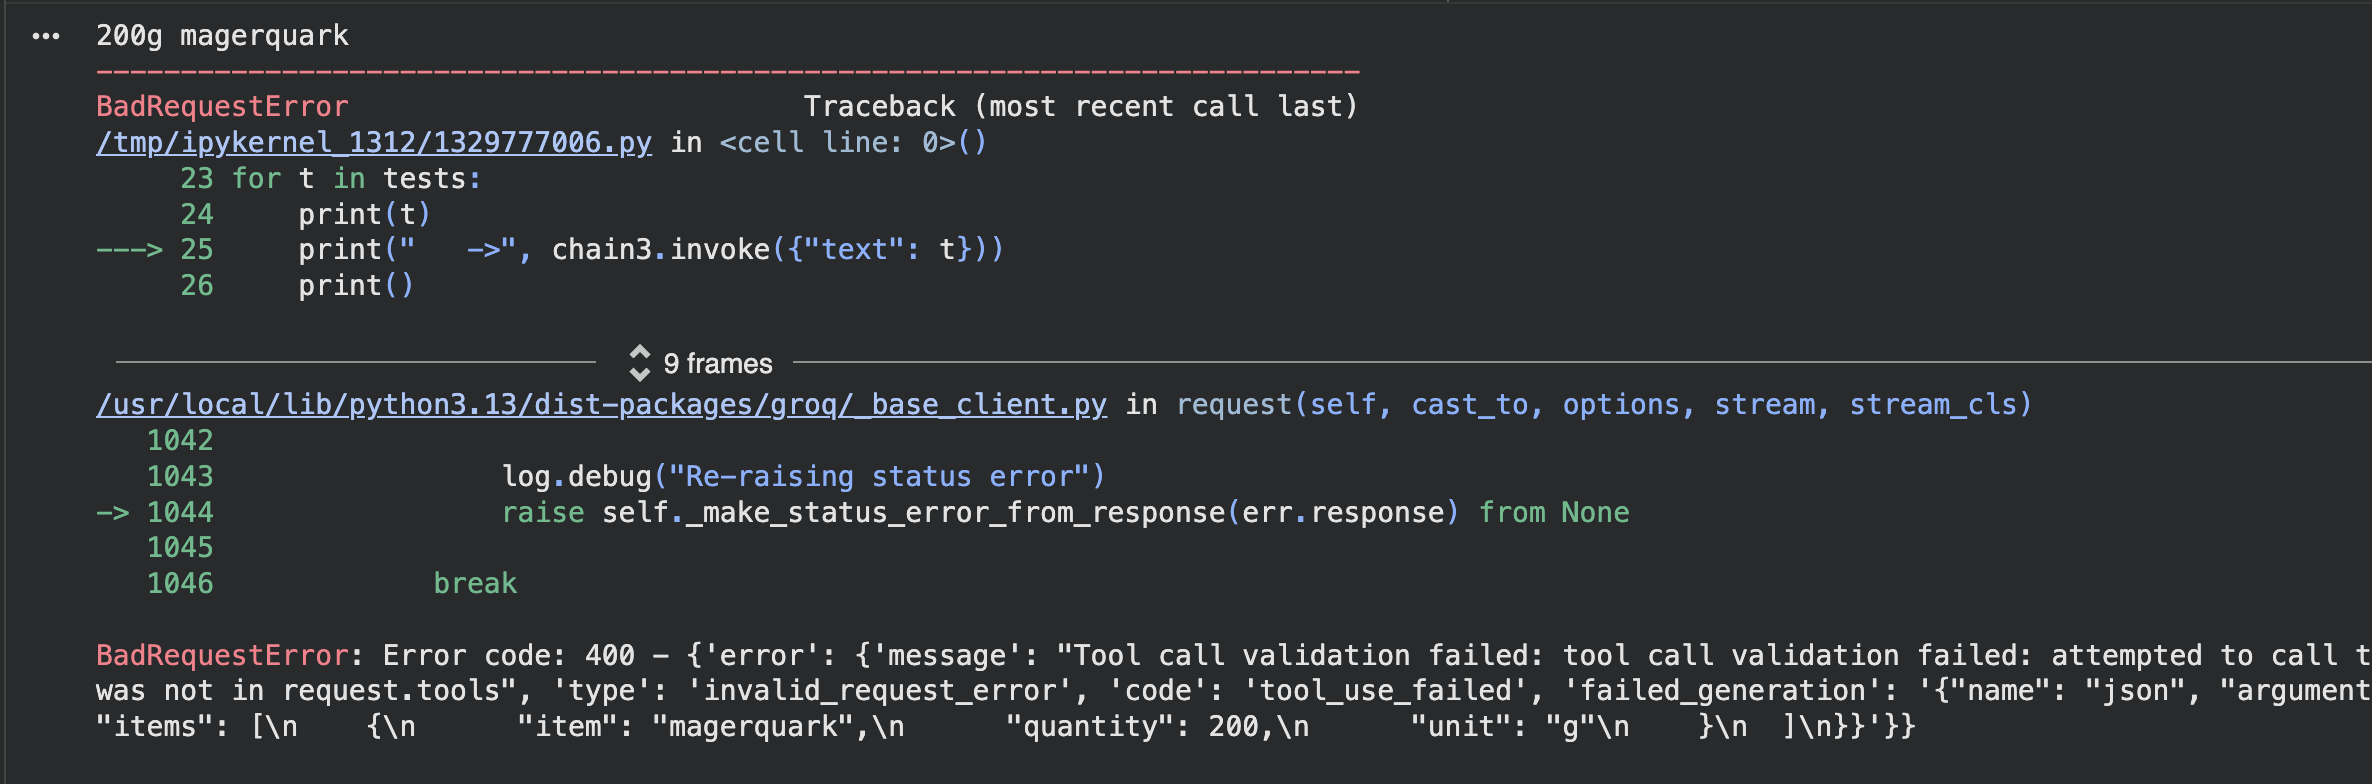)

## Scoreboard: three versions

| # | Input | v1 prompt only | v2 + Pydantic | v3 + Literal |
|---|-------|----------------|---------------|--------------|
| 1 | 200g magerquark | pass | fail — became `quark` | **pass** |
| 2 | 2 boiled eggs | fail — plural, cooking method | fail — unit missing | fail — `boiled` still in name |
| 3 | a handful of almonds | fail — `quantity='handful'` | fail — moved to `unit='handful'` | **pass** |
| 4 | 2 Eier und 200g Magerquark | fail — German kept | **pass** | pass |
| 5 | skipped breakfast today | pass | pass | pass |

**2/5 → 2/5 → 4/5**

### What each version changed

**v1 → v2.** Adding a Pydantic schema did not move the score.
Two failures fixed, one new failure created (`magerquark` lost its
fat level), one failure relocated: `'handful'` was blocked from
`quantity` so it moved into `unit`, the neighbouring field that
still accepted text.

Narrowing one field pushes bad data into whichever field is still loose.

**v2 → v3.** Two changes: `unit` restricted to a fixed list with
`Literal`, and the `item` description told to keep words like
`mager`. Both worked. Score moved to 4/5.

### Open issue: context-dependent output

Case 1 returns `magerquark`. Case 4 returns `low-fat quark`.
Same word, same model, same schema, `temperature=0`.

The difference is the surrounding text. In case 4 the word sits next
to German (`Eier und`), and the model translates it along with the
rest. Alone, it does not.

This matters because a lookup table needs one key per food. The same
item arriving under two names produces two rows for one food.

It also defeats single-case testing: `magerquark` passes on its own
and only fails in company.

### Unresolved spec question

Case 2 returns `boiled egg`. Is that wrong? The spec does not say
whether cooking method belongs in the item name. For protein lookup,
boiled and raw eggs are close. For fried eggs they are not — oil
changes the calories.

The ambiguity is in the spec, not the model.

### Measured: 14% infrastructure failure rate

50 calls (5 inputs × 10 rounds). 7 failed with BadRequestError 400.

The failures are not input-specific. Across runs the error landed on
different cases, including `skipped breakfast today`, which produces
the simplest possible output (an empty list).

14% is a wrapper failure, not an accuracy failure. The model's content
was correct in the cases inspected — only the tool name was wrong.

Any pass rate measured with this setup carries a 14% floor of noise.

In [11]:
from typing import Literal
from collections import Counter

Unit = Literal["g", "ml", "piece", "scoop", "tbsp", "tsp", "cup"]

class FoodItem(BaseModel):
    item: str = Field(
        description="food name, lowercase, singular, English. Keep words like 'mager' or 'low-fat' that change the food's nutrition."
    )
    quantity: Optional[float] = Field(
        default=None,
        description="a number only. null if no amount was stated"
    )
    unit: Optional[Unit] = Field(
        default=None,
        description="null if no unit was stated"
    )

class ParsedEntry(BaseModel):
    items: List[FoodItem]

chain3 = prompt | llm.with_structured_output(ParsedEntry, method="json_mode")

errors = Counter()
for run in range(10):
    for t in tests:
        try:
            chain3.invoke({"text": t})
        except Exception as e:
            errors[type(e).__name__] += 1

print(errors)
print(f"{sum(errors.values())}/50")

Counter({'OutputParserException': 10})
10/50
